# AdamW vs Muon: fine-tuning BERT-small on SST-2

This notebook fine-tunes a small pretrained BERT on SST-2 with AdamW and with Muon under the same setup.
It records how the two optimizers behave and estimates how sharp or flat the final solutions are.

**How to run:** Runtime > Change runtime type > T4 GPU, then Runtime > Run all.

**Outputs** go to one folder, `results/`:

| file | contents |
|---|---|
| `runs.json` | every metric from every run |
| `summary.md` | the results table |
| `figure.png`, `figure.pdf` | all plots |
| `numbers.tex` | the table numbers for the LaTeX report |

Model checkpoints go to `checkpoints/` and are not part of the submission.
If Colab disconnects, run all again: finished runs are skipped (keep `USE_DRIVE = True`).

## 1. Setup
A red pip warning about `gradio` or `diffusers` is harmless. Those packages are not used here.

In [1]:
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q "transformers>=4.46,<5" datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 48.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import os, json, math, time, random, statistics
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU (no GPU found, this will be slow)")

device: Tesla T4


In [3]:
# ---------------- configuration ----------------
QUICK = False        # True: small data, 2 learning rates, 2 seeds. A few minutes, for testing only.
USE_DRIVE = True     # save to Google Drive so a disconnect does not lose finished runs

MODEL = "google/bert_uncased_L-4_H-512_A-8"   # BERT-small, 29M parameters
LRS = [3e-5, 1e-4, 3e-4, 1e-3]                 # same grid for both optimizers
SEEDS = [0, 1, 2]
SWEEP_EPOCHS, EPOCHS = 1, 2
BATCH_SIZE, MAX_LEN = 32, 64
WEIGHT_DECAY, WARMUP = 0.01, 0.06
TRAIN_SUBSET = None       # None = full training set
LOG_EVERY, EVAL_EVERY, SHARP_EVERY = 25, 250, 500
PROBE_SIZE = 512          # fixed training examples used for all sharpness measurements
RHO = 0.2                 # radius for worst-case sharpness (relative to weight size)
# ------------------------------------------------
if QUICK:
    LRS, SEEDS, TRAIN_SUBSET = [1e-4, 1e-3], [0, 1], 4000
    EVAL_EVERY, SHARP_EVERY, PROBE_SIZE = 50, 100, 128

WORKDIR = "/content/sst2-optimizers"
if USE_DRIVE and IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    WORKDIR = "/content/drive/MyDrive/sst2-optimizers"
RESULTS = f"{WORKDIR}/results_quick" if QUICK else f"{WORKDIR}/results"
CKPT = f"{WORKDIR}/checkpoints_quick" if QUICK else f"{WORKDIR}/checkpoints"
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(CKPT, exist_ok=True)
print("results folder:", RESULTS)

Mounted at /content/drive
results folder: /content/drive/MyDrive/sst2-optimizers/results


## 2. Data and model

* **Test set.** SST-2 test labels are hidden, so the official validation set (872 sentences) is the test set. It is never used to make a decision.
* **Validation set.** 2,000 training examples are held out for choosing the learning rate.
* **Attention.** The model uses plain (eager) attention because the Hessian measurements need second derivatives, which the fused attention kernels do not support.

In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def load_sst2():
    ds = load_dataset("nyu-mll/glue", "sst2")
    train = list(zip(ds["train"]["sentence"], ds["train"]["label"]))
    test = list(zip(ds["validation"]["sentence"], ds["validation"]["label"]))
    return train, test

def load_tokenizer():
    try:
        return AutoTokenizer.from_pretrained(MODEL)
    except Exception:
        return AutoTokenizer.from_pretrained("bert-base-uncased")   # same vocabulary

def load_model(seed):
    torch.manual_seed(seed)   # same seed gives the same classifier head for both optimizers
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL, num_labels=2, attn_implementation="eager").to(DEVICE)

In [5]:
train_all, test_raw = load_sst2()
tokenizer = load_tokenizer()

order = list(range(len(train_all)))
random.Random(12345).shuffle(order)
val_raw = [train_all[i] for i in order[:2000]]
train_raw = [train_all[i] for i in order[2000:]]
if TRAIN_SUBSET:
    train_raw = train_raw[:TRAIN_SUBSET]

def encode(pairs):
    ids = tokenizer([t for t, _ in pairs], truncation=True, max_length=MAX_LEN)["input_ids"]
    return list(zip(ids, [y for _, y in pairs]))

def collate(batch):
    L = max(len(ids) for ids, _ in batch)
    input_ids = torch.full((len(batch), L), tokenizer.pad_token_id)
    mask = torch.zeros((len(batch), L), dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        input_ids[i, :len(ids)] = torch.tensor(ids)
        mask[i, :len(ids)] = 1
    return {"input_ids": input_ids, "attention_mask": mask, "labels": torch.tensor([y for _, y in batch])}

def to_device(b):
    return {k: v.to(DEVICE) for k, v in b.items()}

def fixed_batches(examples, bs):
    return [to_device(collate(examples[i:i + bs])) for i in range(0, len(examples), bs)]

train_data = encode(train_raw)
val_batches = fixed_batches(encode(val_raw), 256)
test_batches = fixed_batches(encode(test_raw), 256)
probe = [train_data[i] for i in random.Random(999).sample(range(len(train_data)), PROBE_SIZE)]
probe_batches = fixed_batches(probe, 64)
print(f"train {len(train_data)}, val {len(val_raw)}, test {len(test_raw)}, probe {len(probe)}")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

train 65349, val 2000, test 872, probe 512


## 3. Muon

For each hidden weight matrix Muon does three things:
1. It keeps a momentum buffer of the gradient.
2. It replaces the momentum matrix M = USV^T by roughly UV^T, using a few Newton-Schulz iterations. Every direction in the update then gets the same size.
3. It takes a step. The step is scaled by 0.2 * sqrt(max(rows, cols)) so its average entry size (about 0.2) matches a typical AdamW step. That lets both optimizers share one learning-rate grid.

Weight decay is applied the same way as in AdamW.

In [6]:
@torch.no_grad()
def newton_schulz(G, steps=5):
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.float()
    tall = X.shape[0] > X.shape[1]
    if tall:
        X = X.T
    X = X / (X.norm() + 1e-7)
    for _ in range(steps):
        A = X @ X.T
        X = a * X + (b * A + c * A @ A) @ X
    return (X.T if tall else X).to(G.dtype)

class Muon(torch.optim.Optimizer):
    def __init__(self, params, lr, momentum=0.95, weight_decay=0.0):
        super().__init__(params, dict(lr=lr, momentum=momentum, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr, beta, wd = group["lr"], group["momentum"], group["weight_decay"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                buf = self.state[p].setdefault("buf", torch.zeros_like(p))
                buf.lerp_(p.grad, 1 - beta)
                m = p.grad.lerp(buf, beta)                      # Nesterov momentum
                update = newton_schulz(m) * 0.2 * math.sqrt(max(p.shape))
                p.mul_(1 - lr * wd)
                p.add_(update, alpha=-lr)

def is_body_matrix(name, p):
    # attention and feed-forward matrices: these go to Muon
    return p.ndim == 2 and "embeddings" not in name and "classifier" not in name

def make_optimizers(model, opt_name, lr):
    # Muon run: body matrices use Muon, everything else uses the exact AdamW settings of the AdamW run
    muon, decay, no_decay = [], [], []
    for n, p in model.named_parameters():
        if opt_name == "muon" and is_body_matrix(n, p):
            muon.append(p)
        elif p.ndim < 2:
            no_decay.append(p)      # biases and LayerNorm
        else:
            decay.append(p)
    opts = [torch.optim.AdamW([{"params": decay, "weight_decay": WEIGHT_DECAY},
                               {"params": no_decay, "weight_decay": 0.0}], lr=lr)]
    if muon:
        opts.append(Muon(muon, lr=lr, weight_decay=WEIGHT_DECAY))
    return opts

## 4. Measurements

**During training**, and why each one is recorded:

| metric | why |
|---|---|
| train loss, val and test accuracy and loss | the outcome |
| gradient norm | how strong the training signal is, and whether training is unstable |
| update size, \|dW\|/\|W\| per step | the effective step size of each optimizer |
| cos(update, -gradient) | how far each optimizer turns its step away from plain gradient descent |
| distance from the pretrained weights | how far each optimizer travels |
| stable rank of W - W0 | the key structural difference. Muon spreads its change over many directions, while AdamW fine-tuning changes are usually low rank |
| largest Hessian eigenvalue | how curvature evolves during training |
| milliseconds per step | the cost of Muon's extra matrix operations |

**At the end**, four sharpness estimates are computed on the same fixed training subset with dropout off, over all weights except the embedding layer:

1. **Largest Hessian eigenvalue** (worst-case curvature), by power iteration with exact Hessian-vector products.
2. **Hessian trace** (average curvature), by the Hutchinson estimator.
3. **Random-direction sharpness.** The loss increase along random directions scaled to each weight row (filter normalization, Li et al. 2018). Averaging +alpha and -alpha removes the slope and keeps only the curvature.
4. **Worst-case sharpness.** The largest loss increase within a radius measured relative to each weight (as in ASAM, Kwon et al. 2021), found by gradient ascent.

Why four? Estimates 1 and 2 change if weights are rescaled without changing the function (Dinh et al. 2017); estimates 3 and 4 correct for weight scale.
All four also shrink when the model is more confident, so the probe loss and confidence are recorded next to them.
Finally, the loss along the straight line from the AdamW solution to the Muon solution shows whether they sit in the same valley.

In [7]:
@torch.no_grad()
def evaluate(model, batches):
    model.eval()
    loss = correct = conf = n = 0.0
    for b in batches:
        out = model(**b)
        probs = out.logits.float().softmax(-1)
        k = len(b["labels"])
        loss += out.loss.item() * k
        correct += (probs.argmax(-1) == b["labels"]).sum().item()
        conf += probs.max(-1).values.sum().item()
        n += k
    return {"loss": loss / n, "acc": correct / n, "conf": conf / n}

def body_params(model):
    return [p for n, p in model.named_parameters() if "embeddings" not in n]

def dot(a, b):
    return sum((x * y).sum() for x, y in zip(a, b))

def mean_grad(model, params, batches):
    model.eval()
    n = sum(len(b["labels"]) for b in batches)
    total = [torch.zeros_like(p) for p in params]
    for b in batches:
        grads = torch.autograd.grad(model(**b).loss * len(b["labels"]) / n, params)
        for t, g in zip(total, grads):
            t += g
    return total

def hvp(model, params, batches, vec):
    # Hessian-vector product: differentiate (gradient . vec) once more
    model.eval()
    n = sum(len(b["labels"]) for b in batches)
    total = [torch.zeros_like(p) for p in params]
    for b in batches:
        grads = torch.autograd.grad(model(**b).loss * len(b["labels"]) / n, params, create_graph=True)
        for t, h in zip(total, torch.autograd.grad(dot(grads, vec), params)):
            t += h
    return total

def lambda_max(model, batches, iters=20):
    params = body_params(model)
    gen = torch.Generator().manual_seed(0)
    v = [torch.randn(p.shape, generator=gen).to(p) for p in params]
    lam = 0.0
    for _ in range(iters):
        norm = math.sqrt(float(dot(v, v)))
        v = [x / norm for x in v]
        hv = hvp(model, params, batches, v)
        lam = float(dot(v, hv))
        v = hv
    return lam

def hessian_trace(model, batches, samples=10):
    params = body_params(model)
    gen = torch.Generator().manual_seed(1)
    est = []
    for _ in range(samples):
        z = [(torch.randint(0, 2, p.shape, generator=gen) * 2 - 1).to(p) for p in params]
        est.append(float(dot(z, hvp(model, params, batches, z))))
    return statistics.mean(est)

ALPHAS = [-1.0, -0.5, -0.25, -0.1, 0.0, 0.1, 0.25, 0.5, 1.0]

@torch.no_grad()
def random_profile(model, batches, n_dirs=5):
    params = body_params(model)
    orig = [p.clone() for p in params]
    gen = torch.Generator().manual_seed(2)
    base = evaluate(model, batches)["loss"]
    curves = []
    for _ in range(n_dirs):
        dirs = []
        for p in orig:
            d = torch.randn(p.shape, generator=gen).to(p)
            if p.ndim == 2:
                d *= p.norm(dim=1, keepdim=True) / d.norm(dim=1, keepdim=True)   # filter normalization
            else:
                d.zero_()                                                         # skip biases and LayerNorm
            dirs.append(d)
        curve = []
        for a in ALPHAS:
            for p, o, d in zip(params, orig, dirs):
                p.copy_(o + a * d)
            curve.append(evaluate(model, batches)["loss"] - base)
        curves.append(curve)
    for p, o in zip(params, orig):
        p.copy_(o)
    return np.mean(curves, axis=0).tolist()

def worst_case_sharpness(model, batches, rho=RHO, steps=5):
    params = body_params(model)
    orig = [p.detach().clone() for p in params]
    scale = [o.abs() + 0.01 for o in orig]
    base = evaluate(model, batches)["loss"]
    u = [torch.zeros_like(o) for o in orig]           # perturbation = scale * u, with |u| <= rho
    for _ in range(steps):
        with torch.no_grad():
            for p, o, s, x in zip(params, orig, scale, u):
                p.copy_(o + s * x)
        g = [s * x for s, x in zip(scale, mean_grad(model, params, batches))]
        with torch.no_grad():
            gn = math.sqrt(float(dot(g, g))) + 1e-12
            u = [x + (2 * rho / steps) * y / gn for x, y in zip(u, g)]
            un = math.sqrt(float(dot(u, u)))
            if un > rho:
                u = [x * rho / un for x in u]
    with torch.no_grad():
        for p, o, s, x in zip(params, orig, scale, u):
            p.copy_(o + s * x)
        worst = evaluate(model, batches)["loss"]
        for p, o in zip(params, orig):
            p.copy_(o)
    return worst - base

def measure_sharpness(model):
    r = evaluate(model, probe_batches)
    profile = random_profile(model, probe_batches)
    return {
        "probe_loss": r["loss"], "probe_conf": r["conf"],
        "lambda_max": lambda_max(model, probe_batches),
        "trace": hessian_trace(model, probe_batches),
        "profile": profile,
        "random_sharpness": (profile[ALPHAS.index(0.1)] + profile[ALPHAS.index(-0.1)]) / 2,
        "worst_case_sharpness": worst_case_sharpness(model, probe_batches),
    }

@torch.no_grad()
def stable_rank(M):
    s = torch.linalg.svdvals(M.float())
    return float((s ** 2).sum() / s[0] ** 2)

### Correctness checks
1. Newton-Schulz should push all singular values close to 1, and the scaled step should have an average entry size of about 0.2.
2. The Hessian-vector product should match a finite difference of gradients. This is checked on a tiny random BERT in float64.

In [8]:
from transformers import BertConfig, BertForSequenceClassification

torch.manual_seed(0)
G = torch.randn(64, 256) @ torch.diag(torch.logspace(-3, 0, 256))
s = torch.linalg.svdvals(newton_schulz(G))
print(f"Newton-Schulz singular values between {s.min():.2f} and {s.max():.2f}")
print(f"scaled step RMS: {(newton_schulz(torch.randn(512, 2048)) * 0.2 * math.sqrt(2048)).pow(2).mean().sqrt():.3f}")

cfg = BertConfig(vocab_size=100, hidden_size=32, num_hidden_layers=2, num_attention_heads=2,
                 intermediate_size=64, max_position_embeddings=32, num_labels=2)
cfg._attn_implementation = "eager"
tiny = BertForSequenceClassification(cfg).double()
tb = [{"input_ids": torch.randint(5, 100, (8, 12)), "attention_mask": torch.ones(8, 12, dtype=torch.long),
       "labels": torch.randint(0, 2, (8,))}]
ps = body_params(tiny)
v = [torch.randn_like(p) for p in ps]
hv = hvp(tiny, ps, tb, v)
with torch.no_grad():
    for p, x in zip(ps, v): p += 1e-5 * x
gp = mean_grad(tiny, ps, tb)
with torch.no_grad():
    for p, x in zip(ps, v): p -= 2e-5 * x
gm = mean_grad(tiny, ps, tb)
fd = [(a - b) / 2e-5 for a, b in zip(gp, gm)]
err = math.sqrt(sum(float(((h - f) ** 2).sum()) for h, f in zip(hv, fd)) / sum(float((f ** 2).sum()) for f in fd))
print(f"Hessian-vector product error vs finite differences: {err:.1e}")
assert err < 1e-5
del tiny

Newton-Schulz singular values between 0.68 and 1.13
scaled step RMS: 0.191
Hessian-vector product error vs finite differences: 8.7e-09


## 5. Training loop

The setup is the same for both optimizers:
* same learning-rate grid and budget, warmup then linear decay, weight decay 0.01, no gradient clipping;
* for a given seed, the same classifier-head initialization and the same data order.

In [9]:
def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

def train_run(opt_name, lr, seed, epochs, track_sharpness):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    model = load_model(seed)
    body = {n: p for n, p in model.named_parameters() if is_body_matrix(n, p)}
    init = {n: p.detach().clone() for n, p in body.items()}
    init_sq = sum(float((w ** 2).sum()) for w in init.values())
    opts = make_optimizers(model, opt_name, lr)
    loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                        collate_fn=collate, generator=torch.Generator().manual_seed(seed))
    total = int(epochs * len(loader))
    warm = max(1, int(WARMUP * total))
    lr_factor = lambda s: (s + 1) / warm if s < warm else max(0.0, (total - s) / (total - warm))
    scheds = [torch.optim.lr_scheduler.LambdaLR(o, lr_factor) for o in opts]
    hist = {"train": [], "eval": []}
    times, opt_times, ema = [], [], None

    def do_eval(step):
        v, t = evaluate(model, val_batches), evaluate(model, test_batches)
        rec = {"step": step, "val_acc": v["acc"], "val_loss": v["loss"], "test_acc": t["acc"], "test_loss": t["loss"]}
        with torch.no_grad():
            rec["dist_from_init"] = math.sqrt(sum(float(((p - init[n]) ** 2).sum()) for n, p in body.items()) / init_sq)
            if step > 0:
                rec["stable_rank"] = statistics.mean(stable_rank(p - init[n]) for n, p in body.items())
        if track_sharpness and (step % SHARP_EVERY == 0 or step == total):
            rec["lambda_max"] = lambda_max(model, probe_batches, iters=10)
        hist["eval"].append(rec)
        print(f"  step {step:5d}  val acc {rec['val_acc']:.4f}  test acc {rec['test_acc']:.4f}"
              + (f"  lambda_max {rec['lambda_max']:.2f}" if "lambda_max" in rec else ""))
        model.train()

    print(f"{opt_name}  lr={lr:g}  seed={seed}  steps={total}")
    do_eval(0)
    step = 0
    while step < total:
        for batch in loader:
            if step >= total:
                break
            batch = to_device(batch)
            sync(); t0 = time.perf_counter()
            loss = model(**batch).loss
            for o in opts:
                o.zero_grad(set_to_none=True)
            loss.backward()
            sync(); t1 = time.perf_counter()

            log_now = step % LOG_EVERY == 0
            if log_now:   # copy weights and gradients to measure the real update (not timed)
                before = {n: p.detach().clone() for n, p in body.items()}
                grads = {n: p.grad.detach().clone() for n, p in body.items()}
                grad_norm = math.sqrt(sum(float((p.grad ** 2).sum()) for p in model.parameters() if p.grad is not None))

            sync(); t2 = time.perf_counter()
            for o in opts:
                o.step()
            sync(); t3 = time.perf_counter()
            for s in scheds:
                s.step()
            times.append((t1 - t0) + (t3 - t2))
            opt_times.append(t3 - t2)
            ema = loss.item() if ema is None else 0.98 * ema + 0.02 * loss.item()

            if log_now:
                with torch.no_grad():
                    u2 = w2 = g2 = ug = 0.0
                    for n, p in body.items():
                        u = p - before[n]
                        u2 += float((u ** 2).sum()); w2 += float((p ** 2).sum())
                        g2 += float((grads[n] ** 2).sum()); ug += float((-u * grads[n]).sum())
                hist["train"].append({"step": step, "loss_ema": ema, "grad_norm": grad_norm,
                                      "update_size": math.sqrt(u2 / w2),
                                      "update_grad_cos": ug / math.sqrt(u2 * g2 + 1e-30)})
                del before, grads
            step += 1
            if step % EVAL_EVERY == 0 and step < total:
                do_eval(step)
    do_eval(total)

    final, best = hist["eval"][-1], max(hist["eval"][1:], key=lambda r: r["val_acc"])
    tr = hist["train"]
    summary = {
        "optimizer": opt_name, "lr": lr, "seed": seed, "steps": total,
        "val_acc": final["val_acc"], "val_loss": final["val_loss"],
        "test_acc": final["test_acc"], "test_loss": final["test_loss"],
        "test_acc_at_best_val": best["test_acc"], "train_loss": ema,
        "dist_from_init": final["dist_from_init"], "stable_rank": final["stable_rank"],
        "update_size": statistics.mean(r["update_size"] for r in tr[1:] or tr),
        "update_grad_cos": statistics.mean(r["update_grad_cos"] for r in tr[1:] or tr),
        "ms_per_step": 1000 * statistics.median(times), "ms_optimizer": 1000 * statistics.median(opt_times),
    }
    print(f"  done: test acc {summary['test_acc']:.4f}, {summary['ms_per_step']:.1f} ms/step")
    return model, {"summary": summary, "history": hist}

RUNS_FILE = f"{RESULTS}/runs.json"
runs = json.load(open(RUNS_FILE)) if os.path.exists(RUNS_FILE) else {}

def save_runs():
    with open(RUNS_FILE, "w") as f:
        json.dump(runs, f)

def free(model):
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

## 6. Experiments
### 6a. Learning-rate sweep
One seed (100, not used later), one epoch, the same grid for both optimizers. The learning rate is chosen by validation accuracy.

In [10]:
for opt in ["adamw", "muon"]:
    for lr in LRS:
        name = f"sweep_{opt}_{lr:g}"
        if name in runs:
            print("skip", name)
            continue
        model, runs[name] = train_run(opt, lr, seed=100, epochs=SWEEP_EPOCHS, track_sharpness=False)
        save_runs()
        free(model)

BEST_LR = {}
for opt in ["adamw", "muon"]:
    sweep = [runs[f"sweep_{opt}_{lr:g}"]["summary"] for lr in LRS]
    for s in sweep:
        print(f"{opt:6s} lr {s['lr']:g}: val acc {s['val_acc']:.4f}, val loss {s['val_loss']:.4f}")
    BEST_LR[opt] = max(sweep, key=lambda s: (s["val_acc"], -s["val_loss"]))["lr"]
print("chosen:", BEST_LR)

pytorch_model.bin:   0%|          | 0.00/116M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


adamw  lr=3e-05  seed=100  steps=2042


model.safetensors:   0%|          | 0.00/116M [00:00<?, ?B/s]

  step     0  val acc 0.5825  test acc 0.5745
  step   250  val acc 0.8660  test acc 0.8131
  step   500  val acc 0.8895  test acc 0.8303
  step   750  val acc 0.8935  test acc 0.8383
  step  1000  val acc 0.9070  test acc 0.8498
  step  1250  val acc 0.9035  test acc 0.8544
  step  1500  val acc 0.9125  test acc 0.8647
  step  1750  val acc 0.9160  test acc 0.8658
  step  2000  val acc 0.9195  test acc 0.8635
  step  2042  val acc 0.9190  test acc 0.8647
  done: test acc 0.8647, 39.9 ms/step


...

muon  lr=0.0001  seed=100  steps=2042
  step     0  val acc 0.5825  test acc 0.5745
  step   250  val acc 0.8660  test acc 0.8073
  step   500  val acc 0.9015  test acc 0.8394
  step   750  val acc 0.9170  test acc 0.8612
  step  1000  val acc 0.9205  test acc 0.8578
  step  1250  val acc 0.9285  test acc 0.8670
  step  1500  val acc 0.9330  test acc 0.8693
  step  1750  val acc 0.9395  test acc 0.8739
  step  2000  val acc 0.9400  test acc 0.8727
  step  2042  val acc 0.9400  test acc 0.8716
  done: test acc 0.8716, 105.6 ms/step


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


muon  lr=0.0003  seed=100  steps=2042
  step     0  val acc 0.5825  test acc 0.5745
  step   250  val acc 0.8695  test acc 0.8326
  step   500  val acc 0.8910  test acc 0.8486
  step   750  val acc 0.9115  test acc 0.8601
  step  1000  val acc 0.9205  test acc 0.8635
  step  1250  val acc 0.9260  test acc 0.8670
  step  1500  val acc 0.9330  test acc 0.8704
  step  1750  val acc 0.9380  test acc 0.8830
  step  2000  val acc 0.9375  test acc 0.8911
  step  2042  val acc 0.9365  test acc 0.8933
  done: test acc 0.8933, 104.9 ms/step


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


muon  lr=0.001  seed=100  steps=2042
  step     0  val acc 0.5825  test acc 0.5745
  step   250  val acc 0.8585  test acc 0.7993
  step   500  val acc 0.8750  test acc 0.8062
  step   750  val acc 0.8985  test acc 0.8039
  step  1000  val acc 0.9030  test acc 0.8085
  step  1250  val acc 0.9060  test acc 0.8268
  step  1500  val acc 0.9235  test acc 0.8154
  step  1750  val acc 0.9260  test acc 0.8177
  step  2000  val acc 0.9315  test acc 0.8245
  step  2042  val acc 0.9310  test acc 0.8268
  done: test acc 0.8268, 105.1 ms/step
adamw  lr 3e-05: val acc 0.9190, val loss 0.2048
adamw  lr 0.0001: val acc 0.9330, val loss 0.1679
adamw  lr 0.0003: val acc 0.9305, val loss 0.1843
adamw  lr 0.001: val acc 0.5580, val loss 0.6868
muon   lr 3e-05: val acc 0.9095, val loss 0.2329
muon   lr 0.0001: val acc 0.9400, val loss 0.1631
muon   lr 0.0003: val acc 0.9365, val loss 0.1571
muon   lr 0.001: val acc 0.9310, val loss 0.1930
chosen: {'adamw': 0.0001, 'muon': 0.0001}


### 6b. Final runs
Each optimizer is trained with its chosen learning rate on every seed. After each run, the four sharpness estimates are computed and the weights are saved.

In [11]:
for opt in ["adamw", "muon"]:
    for seed in SEEDS:
        name = f"final_{opt}_{seed}"
        if name in runs:
            print("skip", name)
            continue
        model, res = train_run(opt, BEST_LR[opt], seed, EPOCHS, track_sharpness=True)
        print("  measuring sharpness...")
        res["sharpness"] = measure_sharpness(model)
        torch.save({k: v.cpu() for k, v in model.state_dict().items()}, f"{CKPT}/{name}.pt")
        runs[name] = res
        save_runs()
        free(model)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


adamw  lr=0.0001  seed=0  steps=4084
  step     0  val acc 0.4900  test acc 0.5275  lambda_max 111.86
  step   250  val acc 0.8595  test acc 0.8245
  step   500  val acc 0.8905  test acc 0.8475  lambda_max 51.90
  step   750  val acc 0.9080  test acc 0.8601
  step  1000  val acc 0.9110  test acc 0.8521  lambda_max 40.59
  step  1250  val acc 0.9150  test acc 0.8509
  step  1500  val acc 0.9265  test acc 0.8498  lambda_max 25.87
  step  1750  val acc 0.9150  test acc 0.8440
  step  2000  val acc 0.9330  test acc 0.8727  lambda_max 25.17
  step  2250  val acc 0.9340  test acc 0.8612
  step  2500  val acc 0.9350  test acc 0.8578  lambda_max 25.06
  step  2750  val acc 0.9385  test acc 0.8681
  step  3000  val acc 0.9385  test acc 0.8727  lambda_max 23.22
  step  3250  val acc 0.9435  test acc 0.8807
  step  3500  val acc 0.9450  test acc 0.8716  lambda_max 21.84
  step  3750  val acc 0.9470  test acc 0.8807
  step  4000  val acc 0.9455  test acc 0.8842  lambda_max 22.69
  step  4084  val 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


adamw  lr=0.0001  seed=1  steps=4084
  step     0  val acc 0.4410  test acc 0.4931  lambda_max 117.34
  step   250  val acc 0.8580  test acc 0.8142
  step   500  val acc 0.8885  test acc 0.8417  lambda_max 54.56
  step   750  val acc 0.8875  test acc 0.8417
  step  1000  val acc 0.9080  test acc 0.8555  lambda_max 40.21
  step  1250  val acc 0.9220  test acc 0.8658
  step  1500  val acc 0.9225  test acc 0.8635  lambda_max 29.32
  step  1750  val acc 0.9270  test acc 0.8750
  step  2000  val acc 0.9295  test acc 0.8658  lambda_max 25.70
  step  2250  val acc 0.9305  test acc 0.8739
  step  2500  val acc 0.9370  test acc 0.8830  lambda_max 23.20
  step  2750  val acc 0.9355  test acc 0.8830
  step  3000  val acc 0.9375  test acc 0.8739  lambda_max 19.52
  step  3250  val acc 0.9365  test acc 0.8888
  step  3500  val acc 0.9420  test acc 0.8807  lambda_max 19.31
  step  3750  val acc 0.9420  test acc 0.8842
  step  4000  val acc 0.9415  test acc 0.8933  lambda_max 17.19
  step  4084  val 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

muon  lr=0.0001  seed=0  steps=4084
  step     0  val acc 0.4900  test acc 0.5275  lambda_max 111.86
  step   250  val acc 0.8490  test acc 0.8096
  step   500  val acc 0.8930  test acc 0.8498  lambda_max 125.24
  step   750  val acc 0.9080  test acc 0.8658
  step  1000  val acc 0.9180  test acc 0.8693  lambda_max 65.79
  step  1250  val acc 0.9265  test acc 0.8784
  step  1500  val acc 0.9375  test acc 0.8773  lambda_max 50.67
  step  1750  val acc 0.9380  test acc 0.8727
  step  2000  val acc 0.9430  test acc 0.8865  lambda_max 38.43
  step  2250  val acc 0.9435  test acc 0.8819
  step  2500  val acc 0.9485  test acc 0.8761  lambda_max 28.28
  step  2750  val acc 0.9455  test acc 0.8716
  step  3000  val acc 0.9470  test acc 0.8773  lambda_max 46.79
  step  3250  val acc 0.9455  test acc 0.8784
  step  3500  val acc 0.9500  test acc 0.8784  lambda_max 37.36
  step  3750  val acc 0.9475  test acc 0.8842
  step  4000  val acc 0.9470  test acc 0.8853  lambda_max 31.95
  step  4084  val 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


muon  lr=0.0001  seed=1  steps=4084
  step     0  val acc 0.4410  test acc 0.4931  lambda_max 117.34
  step   250  val acc 0.8305  test acc 0.7775
  step   500  val acc 0.8930  test acc 0.8429  lambda_max 160.81
  step   750  val acc 0.8995  test acc 0.8417
  step  1000  val acc 0.9160  test acc 0.8635  lambda_max 85.22
  step  1250  val acc 0.9260  test acc 0.8704
  step  1500  val acc 0.9350  test acc 0.8658  lambda_max 47.93
  step  1750  val acc 0.9330  test acc 0.8727
  step  2000  val acc 0.9360  test acc 0.8853  lambda_max 39.10
  step  2250  val acc 0.9385  test acc 0.8830
  step  2500  val acc 0.9415  test acc 0.8807  lambda_max 43.11
  step  2750  val acc 0.9430  test acc 0.8830
  step  3000  val acc 0.9425  test acc 0.8773  lambda_max 25.03
  step  3250  val acc 0.9425  test acc 0.8899
  step  3500  val acc 0.9455  test acc 0.8773  lambda_max 24.07
  step  3750  val acc 0.9460  test acc 0.8739
  step  4000  val acc 0.9490  test acc 0.8796  lambda_max 26.08
  step  4084  val 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


muon  lr=0.0001  seed=2  steps=4084
  step     0  val acc 0.4465  test acc 0.4805  lambda_max 99.84
  step   250  val acc 0.8200  test acc 0.7810
  step   500  val acc 0.8845  test acc 0.8372  lambda_max 160.69
  step   750  val acc 0.9085  test acc 0.8544
  step  1000  val acc 0.9185  test acc 0.8601  lambda_max 76.41
  step  1250  val acc 0.9310  test acc 0.8693
  step  1500  val acc 0.9350  test acc 0.8647  lambda_max 50.22
  step  1750  val acc 0.9345  test acc 0.8681
  step  2000  val acc 0.9425  test acc 0.8853  lambda_max 40.32
  step  2250  val acc 0.9375  test acc 0.8773
  step  2500  val acc 0.9410  test acc 0.8739  lambda_max 34.05
  step  2750  val acc 0.9445  test acc 0.8853
  step  3000  val acc 0.9400  test acc 0.8796  lambda_max 29.97
  step  3250  val acc 0.9400  test acc 0.8899
  step  3500  val acc 0.9450  test acc 0.8853  lambda_max 28.26
  step  3750  val acc 0.9430  test acc 0.8865
  step  4000  val acc 0.9430  test acc 0.8956  lambda_max 26.20
  step  4084  val a

### 6c. Straight line from the AdamW solution to the Muon solution
This uses the same seed for both, so they share the starting point and the data order.

In [12]:
TS = [-0.2, 0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2]

@torch.no_grad()
def loss_along_line(model, sd_a, sd_b, batches):
    out = []
    for t in TS:
        model.load_state_dict({k: (1 - t) * sd_a[k] + t * sd_b[k] if sd_a[k].is_floating_point() else sd_a[k] for k in sd_a})
        out.append(evaluate(model, batches)["loss"])
    return out

for seed in SEEDS:
    name = f"line_{seed}"
    files = [f"{CKPT}/final_{o}_{seed}.pt" for o in ["adamw", "muon"]]
    if name in runs:
        print("skip", name)
        continue
    if not all(os.path.exists(f) for f in files):
        print(f"missing checkpoints for seed {seed}, skipping")
        continue
    sd_a, sd_b = [{k: v.to(DEVICE) for k, v in torch.load(f, weights_only=True).items()} for f in files]
    model = load_model(0)
    train_line = loss_along_line(model, sd_a, sd_b, probe_batches)
    test_line = loss_along_line(model, sd_a, sd_b, test_batches)
    inside = [(t, l) for t, l in zip(TS, train_line) if 0 <= t <= 1]
    l0, l1 = inside[0][1], inside[-1][1]
    runs[name] = {"seed": seed, "ts": TS, "train_loss": train_line, "test_loss": test_line,
                  "barrier": max(l - ((1 - t) * l0 + t * l1) for t, l in inside)}
    print(f"seed {seed}: loss barrier {runs[name]['barrier']:.4f}")
    save_runs()
    free(model)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


seed 0: loss barrier 0.0172


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


seed 1: loss barrier 0.0092


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-512_A-8 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


seed 2: loss barrier 0.0155


## 7. Results

In [13]:
from IPython.display import Markdown, display

final = {o: [runs[f"final_{o}_{s}"] for s in SEEDS if f"final_{o}_{s}" in runs] for o in ["adamw", "muon"]}
lines_ = [runs[f"line_{s}"] for s in SEEDS if f"line_{s}" in runs]

def values(opt, key, part="summary"):
    return [r[part][key] for r in final[opt]]

def fmt(xs, scale=1, digits=3, tex=False):
    xs = [x * scale for x in xs]
    if not xs:
        return r"\TBD" if tex else "-"
    def num(x, dg):
        s = f"{x:.{dg}g}"
        if tex and "e" in s:
            m, e = s.split("e")
            s = f"{m}\\times 10^{{{int(e)}}}"
        return s
    pm = r" \pm " if tex else " ± "
    body = num(np.mean(xs), digits) + (pm + num(np.std(xs, ddof=1), 2) if len(xs) > 1 else "")
    return f"${body}$" if tex else body

ROWS = [  # label, macro name, key, part, scale, digits
    ("test accuracy (%)", "testacc", "test_acc", "summary", 100, 4),
    ("test accuracy at best val checkpoint (%)", "bestacc", "test_acc_at_best_val", "summary", 100, 4),
    ("test loss", "testloss", "test_loss", "summary", 1, 3),
    ("final train loss", "trainloss", "train_loss", "summary", 1, 3),
    ("ms per step", "ms", "ms_per_step", "summary", 1, 3),
    ("update size per step", "upd", "update_size", "summary", 1, 2),
    ("cos(update, -gradient)", "cos", "update_grad_cos", "summary", 1, 2),
    ("distance from pretrained weights", "dist", "dist_from_init", "summary", 1, 2),
    ("stable rank of W - W0", "srank", "stable_rank", "summary", 1, 3),
    ("probe loss", "probeloss", "probe_loss", "sharpness", 1, 3),
    ("probe confidence", "conf", "probe_conf", "sharpness", 1, 3),
    ("Hessian largest eigenvalue", "lam", "lambda_max", "sharpness", 1, 2),
    ("Hessian trace", "trace", "trace", "sharpness", 1, 2),
    ("random sharpness (alpha 0.1)", "rand", "random_sharpness", "sharpness", 1, 2),
    (f"worst-case sharpness (rho {RHO})", "worst", "worst_case_sharpness", "sharpness", 1, 2),
]

lr_of = lambda o: final[o][0]["summary"]["lr"] if final[o] else None
table = [f"| metric | AdamW (lr {lr_of('adamw')}) | Muon (lr {lr_of('muon')}) |", "|---|---|---|"]
for label, _, key, part, scale, d in ROWS:
    table.append(f"| {label} | {fmt(values('adamw', key, part), scale, d)} | {fmt(values('muon', key, part), scale, d)} |")

paired = [runs[f"final_muon_{s}"]["summary"]["test_acc"] - runs[f"final_adamw_{s}"]["summary"]["test_acc"]
          for s in SEEDS if f"final_muon_{s}" in runs and f"final_adamw_{s}" in runs]
notes = [f"Mean ± std over {len(paired)} seeds.",
         f"Paired test accuracy difference, Muon minus AdamW: {fmt(paired, 100, 2)} points "
         f"(one accuracy on 872 sentences has a standard error of about 0.45 points).",
         f"Loss barrier on the AdamW to Muon line: {fmt([l['barrier'] for l in lines_], 1, 2)}."]
summary_md = "\n".join(table + [""] + notes)
open(f"{RESULTS}/summary.md", "w").write(summary_md)
display(Markdown(summary_md))

macros = {"NSeeds": f"${len(paired)}$", "PairedDiff": fmt(paired, 100, 2, tex=True),
          "Barrier": fmt([l["barrier"] for l in lines_], 1, 2, tex=True), "Rho": f"${RHO}$"}
for opt, P in [("adamw", "AW"), ("muon", "MU")]:
    macros[P + "lr"] = f"${lr_of(opt):g}$" if lr_of(opt) else r"\TBD"
    for _, m, key, part, scale, d in ROWS:
        macros[P + m] = fmt(values(opt, key, part), scale, d, tex=True)
with open(f"{RESULTS}/numbers.tex", "w") as f:
    for k, v in macros.items():
        f.write(f"\\newcommand{{\\{k}}}{{{v}}}\n")

| metric | AdamW (lr 0.0001) | Muon (lr 0.0001) |
|---|---|---|
| test accuracy (%) | 89.07 ± 0.4 | 88.69 ± 0.93 |
| test accuracy at best val checkpoint (%) | 88.42 ± 0.6 | 88.11 ± 0.37 |
| test loss | 0.333 ± 0.011 | 0.372 ± 0.0096 |
| final train loss | 0.124 ± 0.0093 | 0.107 ± 0.0076 |
| ms per step | 45.7 ± 0.097 | 105 ± 0.24 |
| update size per step | 0.00024 ± 5.8e-06 | 0.0002 ± 2.2e-07 |
| cos(update, -gradient) | 0.28 ± 0.00077 | 0.11 ± 0.0019 |
| distance from pretrained weights | 0.075 ± 0.0017 | 0.1 ± 0.00053 |
| stable rank of W - W0 | 9.97 ± 0.052 | 111 ± 2.1 |
| probe loss | 0.0512 ± 0.005 | 0.0329 ± 0.0067 |
| probe confidence | 0.972 ± 0.0011 | 0.983 ± 0.0013 |
| Hessian largest eigenvalue | 17 ± 0.65 | 28 ± 3.2 |
| Hessian trace | 1.7e+02 ± 47 | 2.5e+02 ± 1.2e+02 |
| random sharpness (alpha 0.1) | 0.0015 ± 0.00042 | 0.0023 ± 0.00075 |
| worst-case sharpness (rho 0.2) | 0.0043 ± 0.00033 | 0.0059 ± 0.00045 |

Mean ± std over 3 seeds.
Paired test accuracy difference, Muon minus AdamW: -0.38 ± 1.1 points (one accuracy on 872 sentences has a standard error of about 0.45 points).
Loss barrier on the AdamW to Muon line: 0.014 ± 0.0042.

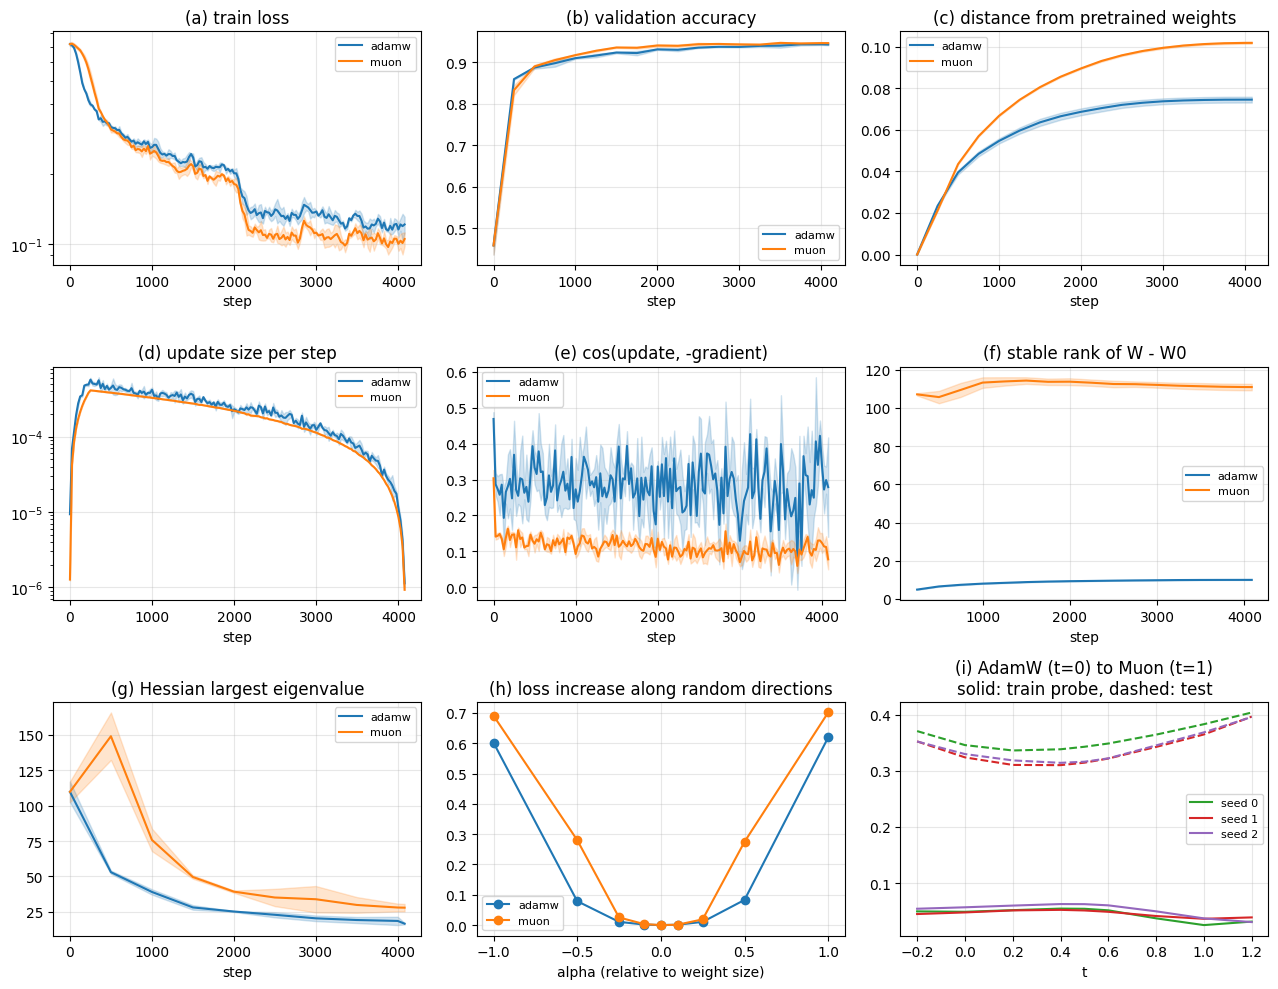

In [14]:
COLORS = {"adamw": "tab:blue", "muon": "tab:orange"}

def curve(opt, part, key):
    series = [{r["step"]: r[key] for r in run["history"][part] if key in r} for run in final[opt]]
    series = [s for s in series if s]
    if not series:
        return None
    steps = sorted(set.intersection(*[set(s) for s in series]))
    arr = np.array([[s[t] for t in steps] for s in series])
    return steps, arr.mean(0), arr.std(0)

panels = [("train", "loss_ema", "(a) train loss", True), ("eval", "val_acc", "(b) validation accuracy", False),
          ("eval", "dist_from_init", "(c) distance from pretrained weights", False),
          ("train", "update_size", "(d) update size per step", True),
          ("train", "update_grad_cos", "(e) cos(update, -gradient)", False),
          ("eval", "stable_rank", "(f) stable rank of W - W0", False),
          ("eval", "lambda_max", "(g) Hessian largest eigenvalue", False)]
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, (part, key, title, log) in zip(axes.flat, panels):
    for opt in COLORS:
        c = curve(opt, part, key)
        if c:
            ax.plot(c[0], c[1], color=COLORS[opt], label=opt)
            ax.fill_between(c[0], c[1] - c[2], c[1] + c[2], color=COLORS[opt], alpha=0.2)
    ax.set(title=title, xlabel="step", yscale="log" if log else "linear")

ax = axes.flat[7]
for opt in COLORS:
    profs = values(opt, "profile", "sharpness")
    if profs:
        ax.plot(ALPHAS, np.mean(profs, axis=0), "o-", color=COLORS[opt], label=opt)
ax.set(title="(h) loss increase along random directions", xlabel="alpha (relative to weight size)")

ax = axes.flat[8]
for i, l in enumerate(lines_):
    ax.plot(l["ts"], l["train_loss"], color=f"C{i + 2}", label=f"seed {l['seed']}")
    ax.plot(l["ts"], l["test_loss"], color=f"C{i + 2}", ls="--")
ax.set(title="(i) AdamW (t=0) to Muon (t=1)\nsolid: train probe, dashed: test", xlabel="t")
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS}/figure.png", dpi=130)
fig.savefig(f"{RESULTS}/figure.pdf")
plt.show()

## 8. Download
This downloads `results.zip`. For the GitHub repo you also need this notebook (File > Download > Download .ipynb), `README.md`, and `report.tex`.

In [15]:
import shutil
zip_path = shutil.make_archive(f"{WORKDIR}/results", "zip", RESULTS)
print("created", zip_path)
if IN_COLAB:
    from google.colab import files
    files.download(zip_path)

created /content/drive/MyDrive/sst2-optimizers/results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>